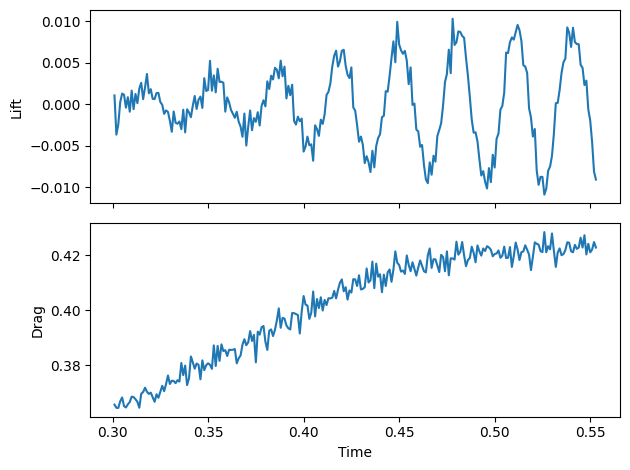

In [112]:
import numpy as np
import matplotlib.pyplot as plt

step, time, drag, lift = np.loadtxt("/Volumes/SherlockScratch/DSMC_FEM_VALIDATION_P1/BEAM_LOCKIN/PHASE_2R/PHASE_0R/BASE/EXAMPLE/lift_drag.dat", skiprows=1, unpack=True)
st = 0.3
lift = lift[time > st]
drag = drag[time > st]
time = time[time > st]
# Quick fake cosine lift data for testing
# lift = 0.5 * np.cos(2 * np.pi * time / 10) + 0.5
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

ax1.plot(time, lift)
ax1.set_ylabel("Lift")

ax2.plot(time, drag)
ax2.set_ylabel("Drag")
ax2.set_xlabel("Time")

# set x limit to 0.15 to 0.25
# and align x axis of both subplots
# ax1.set_xlim(0.15, 0.3)
# ax2.set_xlim(0.15, 0.3)
# ax2.set_ylim(0.2,0.3)

# Plot windowed average
# ax1.plot(time, np.convolve(lift, np.ones(10)/10, mode='same'), color='red', label='Windowed Average')
# ax2.plot(time, np.convolve(drag, np.ones(10)/10, mode='same'), color='red', label='Windowed Average')
plt.tight_layout()
plt.show()

Detected Dominant Frequencies (Lift):
-> Frequency: 31.62 Hz | Amplitude: 0.70
Detected Dominant Frequencies (Drag):
-> Frequency: 3.95 Hz | Amplitude: 2.83
-> Frequency: 31.62 Hz | Amplitude: 0.30


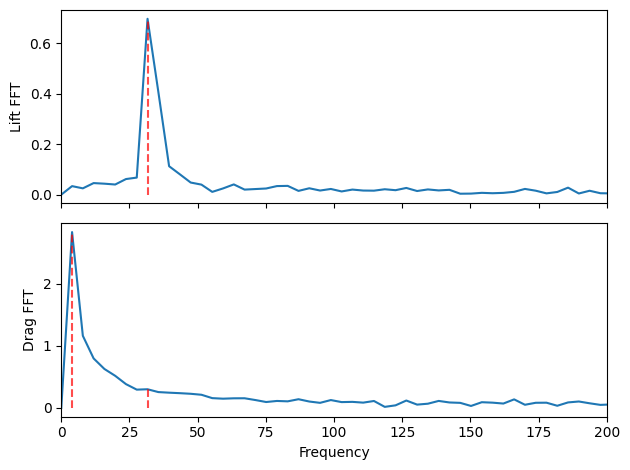

In [113]:
dt = time[1] - time[0]
freq = np.fft.rfftfreq(len(time), d=dt)

lift_fft = np.abs(np.fft.rfft(lift-lift.mean()))
drag_fft = np.abs(np.fft.rfft(drag-drag.mean()))

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

ax1.plot(freq, lift_fft)
ax1.set_ylabel("Lift FFT")
ax1.set_xlim(0,200)
# ax1.set_yscale("log")

ax2.plot(freq, drag_fft)
ax2.set_ylabel("Drag FFT")
ax2.set_xlim(0,200)
ax2.set_xlabel("Frequency")
# ax2.set_yscale("log")

plt.tight_layout()
# plt.show()

from scipy.signal import find_peaks

# (Assuming positive_frequencies and positive_magnitudes are from the previous step)

# 1. Set a threshold to ignore noise (e.g., must be at least 5% of your max expected amplitude)
height_threshold = 0.25

# 2. Find the indices of the peaks
# 'distance' ensures you don't pick adjacent bins for the same broad peak
peak_indices, properties = find_peaks(lift_fft, height=height_threshold, distance=5)

# 3. Extract the actual frequency values and their amplitudes
dominant_frequencies = freq[peak_indices]
dominant_magnitudes = lift_fft[peak_indices]

# 4. Sort them from most dominant to least dominant
sort_order = np.argsort(dominant_magnitudes)[::-1]
sorted_frequencies = dominant_frequencies[sort_order]
sorted_magnitudes = dominant_magnitudes[sort_order]

# 5. Print the results
print("Detected Dominant Frequencies (Lift):")
for freq, amp in zip(sorted_frequencies, sorted_magnitudes):
    print(f"-> Frequency: {freq:.2f} Hz | Amplitude: {amp:.2f}")
    ax1.vlines(freq, 0, amp, color='red', linestyle='--', alpha=0.7, label=f'Detected Peak: {freq:.2f} Hz')

# 2. Find the indices of the peaks
# 'distance' ensures you don't pick adjacent bins for the same broad peak
peak_indices, properties = find_peaks(drag_fft, height=height_threshold, distance=5)

# 3. Extract the actual frequency values and their amplitudes
freq = np.fft.rfftfreq(len(time), d=dt)
dominant_frequencies = freq[peak_indices]
dominant_magnitudes = drag_fft[peak_indices]

# 4. Sort them from most dominant to least dominant
sort_order = np.argsort(dominant_magnitudes)[::-1]
sorted_frequencies = dominant_frequencies[sort_order]
sorted_magnitudes = dominant_magnitudes[sort_order]

# 5. Print the results
print("Detected Dominant Frequencies (Drag):")
for freq, amp in zip(sorted_frequencies, sorted_magnitudes):
    print(f"-> Frequency: {freq:.2f} Hz | Amplitude: {amp:.2f}")
    ax2.vlines(freq, 0, amp, color='red', linestyle='--', alpha=0.7, label=f'Detected Peak: {freq:.2f} Hz')

plt.show()

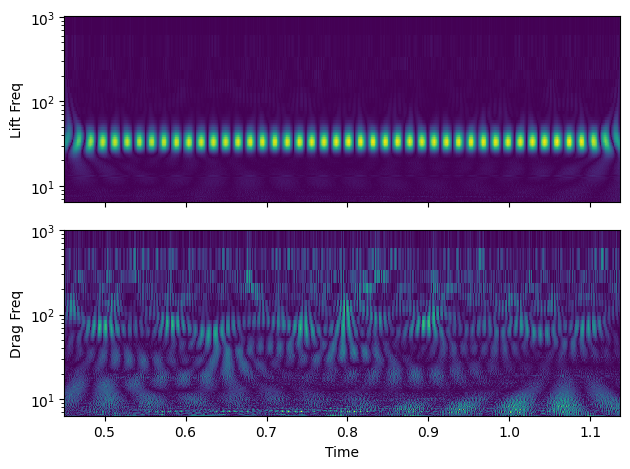

In [61]:
import pywt

scales = np.arange(1, 128)
lift_cwt, cwt_freqs = pywt.cwt(lift - lift.mean(), scales, "morl", sampling_period=dt)
drag_cwt, _ = pywt.cwt(drag - drag.mean(), scales, "morl", sampling_period=dt)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

ax1.pcolormesh(time, cwt_freqs, np.abs(lift_cwt), shading="auto")
ax1.set_ylabel("Lift Freq")

ax2.pcolormesh(time, cwt_freqs, np.abs(drag_cwt), shading="auto")
ax2.set_ylabel("Drag Freq")
ax2.set_xlabel("Time")
ax1.set_yscale("log")
ax2.set_yscale("log")

plt.tight_layout()
plt.show()

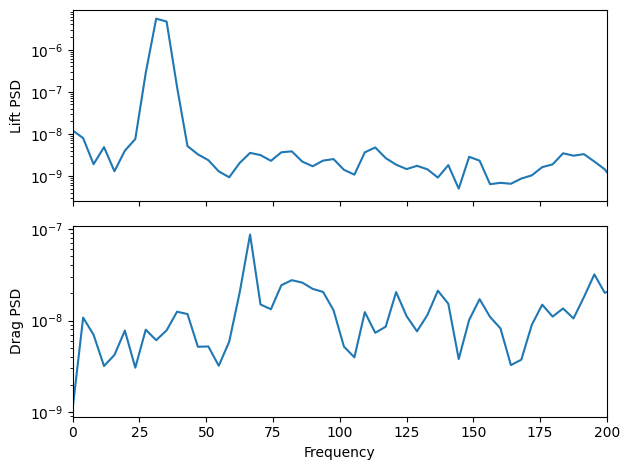

In [62]:
from scipy.signal import welch

f_lift, pxx_lift = welch(lift - lift.mean(), fs=1 / dt)
f_drag, pxx_drag = welch(drag - drag.mean(), fs=1 / dt)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

ax1.semilogy(f_lift, pxx_lift)
ax1.set_ylabel("Lift PSD")

ax2.semilogy(f_drag, pxx_drag)
ax2.set_ylabel("Drag PSD")
ax2.set_xlabel("Frequency")
ax2.set_xlim(0, 200)

plt.tight_layout()
plt.show()

Closest node: id=167, pos=[-8.00457e-05 -3.67422e-05  0.00000e+00]
[0.     0.0001 0.0002 0.0003 0.0004 0.0005 0.0006 0.0007 0.0008 0.0009
 0.001  0.0011 0.0012 0.0013 0.0014 0.0015 0.0016 0.0017 0.0018 0.0019
 0.002  0.0021 0.0022 0.0023 0.0024 0.0025 0.0026 0.0027 0.0028 0.0029
 0.003  0.0031 0.0032 0.0033 0.0034 0.0035 0.0036 0.0037 0.0038 0.0039
 0.004 ]


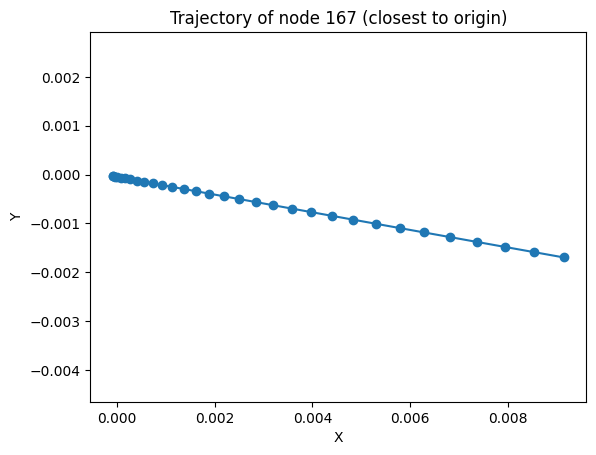

In [35]:
# Smoke test: trajectory of the node closest to the origin
top_path = "/Volumes/SherlockScratch/DSMC_FEM_VALIDATION_P1/ELLIPSE/circle_beam.top"
disp_path = "/Volumes/SherlockScratch/DSMC_FEM_VALIDATION_P1/ELLIPSE/results_ellipse/gdisplac"

with open(disp_path) as f:
    lines = f.readlines()
n_nodes = int(lines[1])

# top file has node rows followed by "Elements ..." sections, so cap the read
node_data = np.loadtxt(top_path, skiprows=1, max_rows=n_nodes)
node_ids = node_data[:, 0].astype(int)
node_xyz = node_data[:, 1:4]

closest_idx = np.argmin(np.linalg.norm(node_xyz[:, :2], axis=1))
closest_idx = 166
print(f"Closest node: id={node_ids[closest_idx]}, pos={node_xyz[closest_idx]}")

times = []
disp = []
i = 2
while i < len(lines):
    times.append(float(lines[i]))
    block = lines[i + 1 : i + 1 + n_nodes]
    disp.append([float(v) for v in block[closest_idx].split()])
    i += 1 + n_nodes

times = np.array(times)
print(times)
disp = np.array(disp)

x0, y0 = node_xyz[closest_idx, 0], node_xyz[closest_idx, 1]
traj_x = x0 + disp[:, 0]
traj_y = y0 + disp[:, 1]

traj_x = traj_x[times <= 3e-3]
traj_y = traj_y[times <= 3e-3]
plt.figure()
plt.plot(traj_x, traj_y, marker="o")
plt.xlabel("X")
plt.ylabel("Y")
plt.title(f"Trajectory of node {node_ids[closest_idx]} (closest to origin)")
plt.axis("equal")
plt.show()